In [48]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import shutil

The aim of the notebook is to generate dataset with the right tree structure for PyTorch.

In [8]:
df = pd.read_csv('dataset_master.csv')

In [12]:
df.head()

,product_name,image,description,_main_cat
0,Elegance Polyester Multicolor Abstract Eyelet ...,55b85ea15a1536d46b7190ad6fff8ce7.jpg,Key Features of Elegance Polyester Multicolor ...,Home Furnishing
1,Sathiyas Cotton Bath Towel,7b72c92c2f6c40268628ec5f14c6d590.jpg,Specifications of Sathiyas Cotton Bath Towel (...,Baby Care
2,Eurospa Cotton Terry Face Towel Set,64d5d4a258243731dc7bbb1eef49ad74.jpg,Key Features of Eurospa Cotton Terry Face Towe...,Baby Care
3,SANTOSH ROYAL FASHION Cotton Printed King size...,d4684dcdc759dd9cdf41504698d737d8.jpg,Key Features of SANTOSH ROYAL FASHION Cotton P...,Home Furnishing
4,Jaipur Print Cotton Floral King sized Double B...,6325b6870c54cd47be6ebfbffa620ec7.jpg,Key Features of Jaipur Print Cotton Floral Kin...,Home Furnishing


In [14]:
df['image'][0]

'55b85ea15a1536d46b7190ad6fff8ce7.jpg'

In [22]:
i = 0
path_name = "Flipkart/Images/" + df['image'][i]
path_name

'Flipkart/Images/55b85ea15a1536d46b7190ad6fff8ce7.jpg'

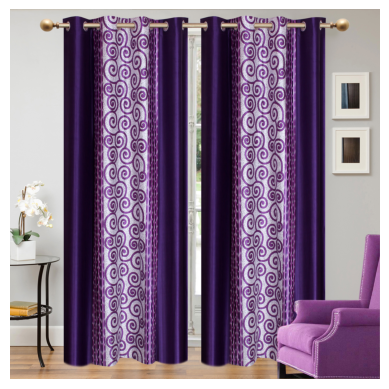

In [30]:
img = mpimg.imread(path_name)
plt.imshow(img)
plt.axis('off')
plt.show()

In [32]:
df['_main_cat'].unique()

array(['Home Furnishing', 'Baby Care', 'Watches',
       'Home Decor & Festive Needs', 'Kitchen & Dining',
       'Beauty and Personal Care', 'Computers'], dtype=object)

# Create an organized dataset with all 1050 images for ViT POC

In [64]:
for i in range(df.shape[0]):
    source_file = "Flipkart/Images/" + df['image'][i]
    cat = df['_main_cat'][i]
    destination_directory = "dataset_VIT/" + cat
    #print(source_file, destination_directory)
    shutil.copy(source_file, destination_directory)

# Create an organized dataset with 950 last images for ViT train

In [ ]:
db_folder = "dataset_VIT_train/"

In [108]:
for i in range(100, df.shape[0]):
    source_file = "Flipkart/Images/" + df['image'][i]
    cat = df['_main_cat'][i]
    destination_directory = db_folder + cat
    shutil.copy(source_file, destination_directory)

In [110]:
# Check number of images per class
for fold in os.listdir(db_folder):
    print(f'{fold:<30} {len(os.listdir(db_folder + fold))}')

Baby Care                      138
Beauty and Personal Care       137
Computers                      144
Home Decor & Festive Needs     136
Home Furnishing                138
Kitchen & Dining               135
Watches                        122


# Create an organized dataset with 100 first images for ViT train

In [113]:
db_folder = "dataset_VIT_test/"

In [115]:
for i in range(0, 100):
    source_file = "Flipkart/Images/" + df['image'][i]
    cat = df['_main_cat'][i]
    destination_directory = db_folder + cat
    shutil.copy(source_file, destination_directory)

In [117]:
# Check number of images per class
for fold in os.listdir(db_folder):
    print(f'{fold:<30} {len(os.listdir(db_folder + fold))}')

Baby Care                      12
Beauty and Personal Care       13
Computers                      6
Home Decor & Festive Needs     14
Home Furnishing                12
Kitchen & Dining               15
Watches                        28
